In [6]:
library('ggplot2')
library('dplyr')

# 5. Creează un bar plot cu vânzările totale pe fiecare lună. Folosește culori diferite pentru lunile de vară (iunie, iulie, august).

In [7]:
df <- read.csv("date_inghetata.csv")
head(df)

,temperatura,vanzari,luna,zi_saptamana
,<int>,<int>,<chr>,<chr>
1,8,25,ianuarie,luni
2,10,35,ianuarie,marti
3,12,45,ianuarie,miercuri
4,15,55,ianuarie,joi
5,18,75,ianuarie,vineri
6,20,85,ianuarie,sambata


In [8]:
total_monthly_sales <- df %>% group_by(luna)  %>%  summarize(suma_vanzari = sum(vanzari),)
total_monthly_sales

luna,suma_vanzari
<chr>,<int>
aprilie,4202
august,3560
decembrie,1117
februarie,2318
ianuarie,2288
iulie,3341
iunie,2919
mai,4923
martie,3378


In [9]:
total_monthly_sales <- total_monthly_sales %>% mutate(
        luna = factor(luna, levels=c('ianuarie','februarie','martie','aprilie','mai','iunie','iulie','august','septembrie','octombrie','noiembrie','decembrie'))
) %>% arrange(luna)
total_monthly_sales

luna,suma_vanzari
<fct>,<int>
ianuarie,2288
februarie,2318
martie,3378
aprilie,4202
mai,4923
iunie,2919
iulie,3341
august,3560
septembrie,3111


# Plot Fara culori

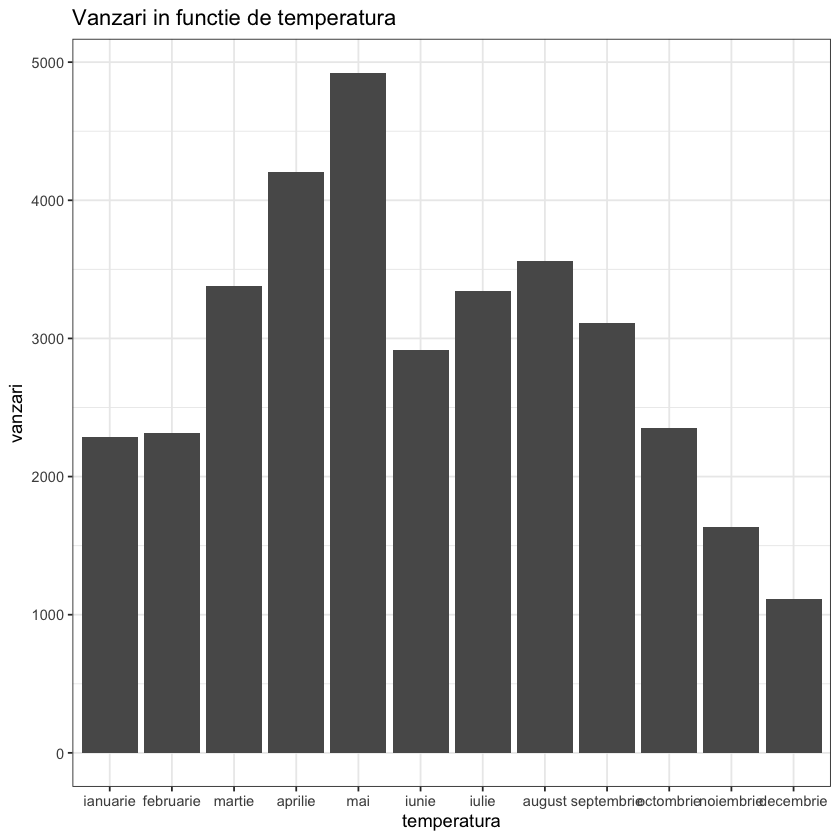

In [14]:

ggplot(data = total_monthly_sales, aes(x = luna, y = suma_vanzari)) + geom_bar(stat = "identity") + labs(x = "temperatura", y = "vanzari" , title= "Vanzari in functie de temperatura") + scale_colour_manual(values = c("#00FF00", "#0000ff")) + theme_bw()

# Plot cu culori

In [15]:
total_monthly_sales

luna,suma_vanzari
<fct>,<int>
ianuarie,2288
februarie,2318
martie,3378
aprilie,4202
mai,4923
iunie,2919
iulie,3341
august,3560
septembrie,3111


In [18]:
total_monthly_sales$sezon = ifelse( total_monthly_sales$luna %in% c("iunie", "iulie", "august"), "vara", "rest" )
total_monthly_sales

luna,suma_vanzari,sezon
<fct>,<int>,<chr>
ianuarie,2288,rest
februarie,2318,rest
martie,3378,rest
aprilie,4202,rest
mai,4923,rest
iunie,2919,vara
iulie,3341,vara
august,3560,vara
septembrie,3111,rest


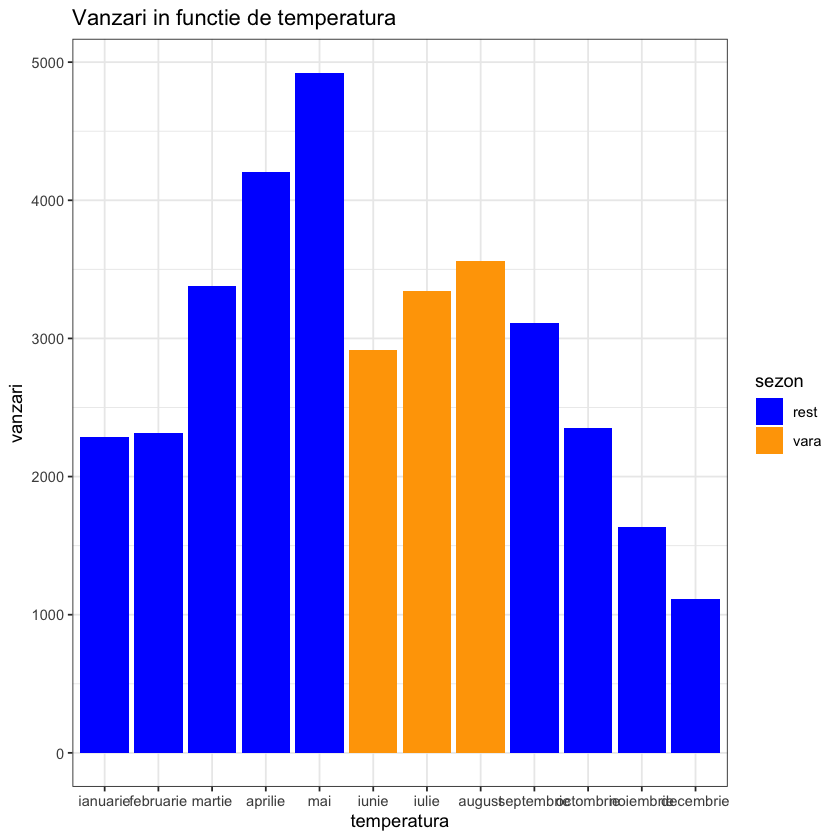

In [20]:

ggplot(data = total_monthly_sales, aes(x = luna, y = suma_vanzari, fill=sezon)) + geom_bar(stat = "identity") + labs(x = "temperatura", y = "vanzari" , title= "Vanzari in functie de temperatura") + scale_colour_manual(values = c("#00FF00", "#0000ff")) +scale_fill_manual(values = c("vara"="orange", "rest"="blue")) + theme_bw()